In [1]:
# se utiliza para el manejo de rutas y directorios.
import os

# Calculo cientifico y vectorial para python
import numpy as np

# Librerias para graficar
from matplotlib import pyplot

# Modulo de optimización de scipy
from scipy import optimize

# le dice a matplotlib que incruste gráficos en el cuaderno
%matplotlib inline


In [2]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from datetime import datetime

In [3]:
dataset = pd.read_csv('/content/Bank_registries.csv')
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [4]:
#eliminamos columnas innecesarias
columnas_eliminadas= ['RowNumber', 'CustomerId','Surname','CreditScore']
dataset.drop(columnas_eliminadas, axis=1, inplace=True)


In [5]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Geography        10000 non-null  object 
 1   Gender           10000 non-null  object 
 2   Age              10000 non-null  int64  
 3   Tenure           10000 non-null  int64  
 4   Balance          10000 non-null  float64
 5   NumOfProducts    10000 non-null  int64  
 6   HasCrCard        10000 non-null  int64  
 7   IsActiveMember   10000 non-null  int64  
 8   EstimatedSalary  10000 non-null  float64
 9   Exited           10000 non-null  int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 781.4+ KB


In [6]:
#Conversion de object a int
columnas_categorias= dataset.select_dtypes(include=['object']).columns

In [7]:
#procesamiento
for columna in columnas_categorias:
  le=LabelEncoder()
  dataset[columna]=le.fit_transform(dataset[columna])

In [8]:
dataset.info()
print(dataset)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Geography        10000 non-null  int64  
 1   Gender           10000 non-null  int64  
 2   Age              10000 non-null  int64  
 3   Tenure           10000 non-null  int64  
 4   Balance          10000 non-null  float64
 5   NumOfProducts    10000 non-null  int64  
 6   HasCrCard        10000 non-null  int64  
 7   IsActiveMember   10000 non-null  int64  
 8   EstimatedSalary  10000 non-null  float64
 9   Exited           10000 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 781.4 KB
      Geography  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0             0       0   42       2       0.00              1          1   
1             2       0   41       1   83807.86              1          0   
2             0       0   42       8  159660.80          

In [9]:
# Importar libreria para dividir entrenamiento y prueba
from sklearn.model_selection import train_test_split
# Division de dataset en entrenamiento y prueba
train_data, test_data = train_test_split(dataset, test_size=0.2, random_state=42)

In [10]:
train_data.info()
print("-"*80)
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 8000 entries, 9254 to 7270
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Geography        8000 non-null   int64  
 1   Gender           8000 non-null   int64  
 2   Age              8000 non-null   int64  
 3   Tenure           8000 non-null   int64  
 4   Balance          8000 non-null   float64
 5   NumOfProducts    8000 non-null   int64  
 6   HasCrCard        8000 non-null   int64  
 7   IsActiveMember   8000 non-null   int64  
 8   EstimatedSalary  8000 non-null   float64
 9   Exited           8000 non-null   int64  
dtypes: float64(2), int64(8)
memory usage: 687.5 KB
--------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
Int64Index: 2000 entries, 6252 to 6929
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0 

In [66]:
#Creamos los datas de entrenamiento y prueba
train_data.to_csv("train.csv", index=False)
test_data.to_csv("test.csv", index=False)

In [11]:
dataset = pd.read_csv('/content/train.csv')

In [12]:
X = dataset.iloc[:, :9]
y = dataset.iloc[:, 9]
print(X)

      Geography  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0             0       1   32       6       0.00              2          1   
1             1       1   42       4  119624.60              2          1   
2             2       1   24       3  114739.92              1          1   
3             0       0   27       9  135637.00              1          1   
4             0       1   56       9  142147.32              1          0   
...         ...     ...  ...     ...        ...            ...        ...   
7995          0       1   54       8   69712.74              1          1   
7996          0       0   58       1       0.00              1          1   
7997          0       0   38       1       0.00              3          0   
7998          0       1   43       8  190227.46              1          1   
7999          1       1   51       1  147910.30              1          1   

      IsActiveMember  EstimatedSalary  
0                  1        179093.

In [13]:
# Normaliza entre -0.5 y 0.5
def  featureNormalize(X):
    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [14]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)
print(X)
print(X_norm)

      Geography  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0             0       1   32       6       0.00              2          1   
1             1       1   42       4  119624.60              2          1   
2             2       1   24       3  114739.92              1          1   
3             0       0   27       9  135637.00              1          1   
4             0       1   56       9  142147.32              1          0   
...         ...     ...  ...     ...        ...            ...        ...   
7995          0       1   54       8   69712.74              1          1   
7996          0       0   58       1       0.00              1          1   
7997          0       0   38       1       0.00              3          0   
7998          0       1   43       8  190227.46              1          1   
7999          1       1   51       1  147910.30              1          1   

      IsActiveMember  EstimatedSalary  
0                  1        179093.

In [15]:
def sigmoid(z):
    # Calcula la sigmoide de una entrada z
    # convierte la intrada a un arreglo numpy
    z = np.array(z)

    g = np.zeros(z.shape)

    g = 1 / (1 + np.exp(-z))

    return g

In [16]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = X.shape
# Agraga el termino de intercepción a A
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [17]:
print(X[1])

[ 1.          0.30164867  0.91324755  0.29493847 -0.3483691   0.69683765
  0.80843615  0.64920267  0.97481699  1.6612541 ]


In [18]:
def calcularCosto(theta, X, y):
    # Inicializar algunos valores utiles
    m = y.size  # numero de ejemplos de entrenamiento

    J = 0
    h = sigmoid(X.dot(theta.T))
    J = (1 / m) * np.sum(-y.dot(np.log(h)) - (1 - y).dot(np.log(1 - h)))

    return J

In [19]:
def descensoGradiente(theta, X, y, alpha, num_iters):
    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        h = sigmoid(X.dot(theta.T))
        theta = theta - (alpha / m) * (h - y).dot(X)

        J_history.append(calcularCosto(theta, X, y))
    return theta, J_history

In [20]:
#cargamos el dataset de Prueba
dataset = pd.read_csv('/content/test.csv')

In [21]:
print(dataset)

      Geography  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0             1       1   32       3   96709.07              2          0   
1             0       1   43       1       0.00              2          1   
2             2       0   44       4       0.00              2          1   
3             1       1   59       8  119152.10              2          1   
4             2       0   27       7  124995.98              1          1   
...         ...     ...  ...     ...        ...            ...        ...   
1995          1       0   53       5   98268.84              1          0   
1996          0       1   25      10       0.00              1          0   
1997          0       0   47       7       0.00              1          1   
1998          0       1   29       4       0.00              1          1   
1999          1       1   39       1  115341.19              1          1   

      IsActiveMember  EstimatedSalary  Exited  
0                  0       

In [22]:
x_test = dataset.iloc[:, :9]
y_test = dataset.iloc[:, 9]
print(X)

[[ 1.         -0.9055496   0.91324755 ...  0.64920267  0.97481699
   1.36766974]
 [ 1.          0.30164867  0.91324755 ...  0.64920267  0.97481699
   1.6612541 ]
 [ 1.          1.50884694  0.91324755 ...  0.64920267 -1.02583358
  -0.25280688]
 ...
 [ 1.         -0.9055496  -1.09499335 ... -1.54035103 -1.02583358
  -0.1427649 ]
 [ 1.         -0.9055496   0.91324755 ...  0.64920267 -1.02583358
  -0.05082558]
 [ 1.          0.30164867  0.91324755 ...  0.64920267  0.97481699
  -0.81456811]]


In [23]:
X_norm_test, mu_test, sigma_test = featureNormalize(x_test)
print(X_norm_test)

      Geography    Gender       Age    Tenure   Balance  NumOfProducts  \
0      0.326537  0.909112 -0.677299 -0.698445  0.300846       0.805105   
1     -0.887356  0.909112  0.384298 -1.380355 -1.255997       0.805105   
2      1.540431 -1.099975  0.480807 -0.357491 -1.255997       0.805105   
3      0.326537  0.909112  1.928440  1.006327  0.662139       0.805105   
4      1.540431 -1.099975 -1.159844  0.665373  0.756215      -0.891639   
...         ...       ...       ...       ...       ...            ...   
1995   0.326537 -1.099975  1.349387 -0.016536  0.325956      -0.891639   
1996  -0.887356  0.909112 -1.352861  1.688237 -1.255997      -0.891639   
1997  -0.887356 -1.099975  0.770334  0.665373 -1.255997      -0.891639   
1998  -0.887356  0.909112 -0.966826 -0.357491 -1.255997      -0.891639   
1999   0.326537  0.909112 -0.001737 -1.380355  0.600790      -0.891639   

      HasCrCard  IsActiveMember  EstimatedSalary  
0     -1.578101       -1.050262        -0.990969  
1      0.

In [24]:
# Configurar la matriz adecuadamente, y agregar una columna de unos que corresponde al termino de intercepción.
m, n = x_test.shape
# Agraga el termino de intercepción a A
X_t = np.concatenate([np.ones((m, 1)), X_norm_test], axis=1)
print(X_t[1999])

[ 1.          0.32653736  0.90911166 -0.00173716 -1.38035469  0.60079031
 -0.89163935  0.63367318  0.95214374  0.15573964]


theta calculado por el descenso por el gradiente: [-1.58038547  0.08647308 -0.26130411  0.73215807 -0.03777099  0.29092241
 -0.03154354 -0.00241388 -0.51414901  0.01965556]
Un estudiante con nota del examen 1: 0.32653736 y nota del examen 2: 0.90911166 (usando el descenso por el gradiente):0.1167120668286642


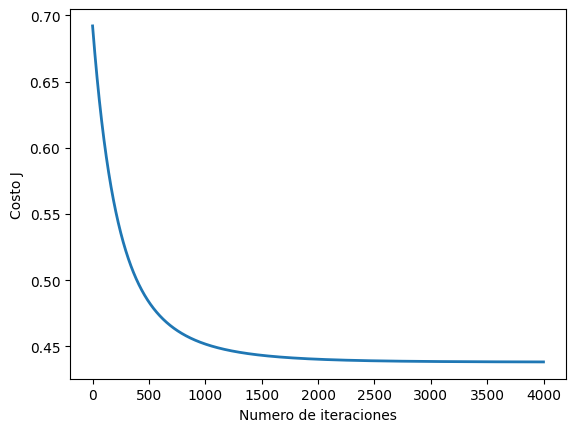

In [43]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.01
num_iters = 4000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(10)
theta, J_history = descensoGradiente(theta, X, y, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))

# verificacion de efectiviadad del modelo con los primeros y ultimos 2 valores del data set de Prueba
#X_array = [1. ,   0.32653736 , 0.90911166 ,-0.67729931, -0.69844549 , 0.30084641,0.80510537 ,-1.57810057, -1.0502616 , -0.99096946] #0.15
#X_array = [1. ,-0.88735616 , 0.90911166 , 0.38429835, -1.38035469 ,-1.25599716,0.80510537 , 0.63367318,  0.95214374 , 0.8293793]     #0.081
#X_array = [1. , -0.88735616 , 0.90911166 ,-0.96682594 ,-0.3574909 , -1.25599716,-0.89163935 , 0.63367318, -1.0502616 , -0.38237688]  #0.083
X_array = [1. , 0.32653736, 0.90911166, -0.00173716 ,-1.38035469 , 0.60079031,-0.89163935 , 0.63367318 , 0.95214374 , 0.15573964]     #0.116

aprueba = sigmoid(np.dot(X_array, theta))   # Se debe cambiar esto

print(f"Un estudiante con nota del examen 1: {X_array[1]} y nota del examen 2: {X_array[2]} (usando el descenso por el gradiente):{aprueba}")